In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Sleep_Health_and_Lifestyle_Dataset.csv")  # path from notebooks folder

In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
# Keep only the columns needed for H7
df_h4 = df[["Stress Level", "Sleep Duration"]]

# Check the first few rows to confirm
df_h4.head()

,Stress Level,Sleep Duration
0,6,6.1
1,8,6.2
2,8,6.2
3,8,5.9
4,8,5.9


In [ ]:
#removing the missing values 
df_h4.isnull().sum()
df_h4 = df_h4.dropna()

In [ ]:
#removing invalid values
df_h4 = df_h4[(df_h4["Sleep Duration"] > 0) & (df_h4["Sleep Duration"] <= 24)]
df_h4 = df_h4[(df_h4["Stress Level"] >= 1) & (df_h4["Stress Level"] <= 10)]

In [ ]:
# Adjust thresholds
df_h4["HighStress"] = (df_h4["Stress Level"] > 6).astype(int)
df_h4["LowSleep"] = (df_h4["Sleep Duration"] < 7).astype(int)


In [ ]:
df_h4.head()
df_h4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Stress Level    374 non-null    int64  
 1   Sleep Duration  374 non-null    float64
 2   HighStress      374 non-null    int64  
 3   LowSleep        374 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 11.8 KB


In [ ]:
# Create contingency table
contingency_table = pd.crosstab(df_h4["HighStress"], df_h4["LowSleep"])
contingency_table

LowSleep,0,1
HighStress,,
0,219,35
1,0,120


In [ ]:
from scipy.stats import chi2_contingency

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)


Chi-Square Statistic: 246.109770288049
p-value: 1.8305052694737202e-55
Degrees of Freedom: 1
Expected Frequencies:
 [[148.73262032 105.26737968]
 [ 70.26737968  49.73262032]]


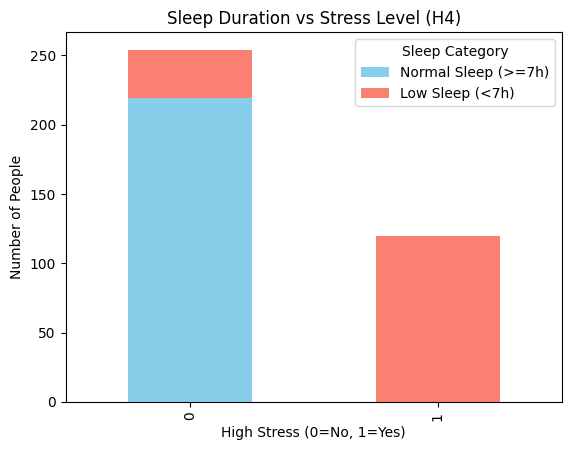

In [ ]:
import matplotlib.pyplot as plt

# Create contingency table again (if needed)
contingency_table = pd.crosstab(df_h4["HighStress"], df_h4["LowSleep"])

# Plot
contingency_table.plot(kind='bar', stacked=True, color=['skyblue','salmon'])
plt.title('Sleep Duration vs Stress Level (H4)')
plt.xlabel('High Stress (0=No, 1=Yes)')
plt.ylabel('Number of People')
plt.legend(["Normal Sleep (>=7h)", "Low Sleep (<7h)"], title="Sleep Category")
plt.show()


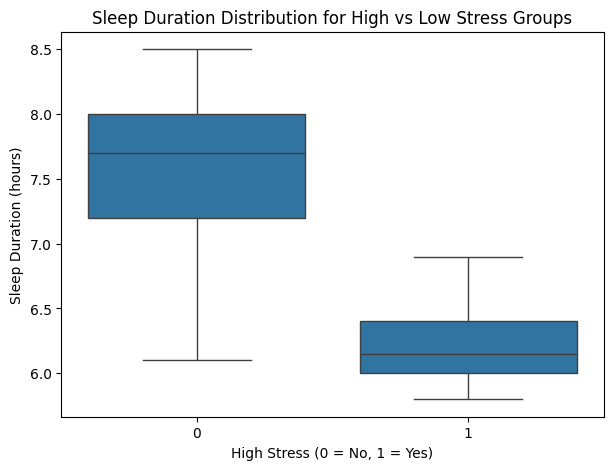

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(x=df_h4["HighStress"], y=df_h4["Sleep Duration"])
plt.title("Sleep Duration Distribution for High vs Low Stress Groups")
plt.xlabel("High Stress (0 = No, 1 = Yes)")
plt.ylabel("Sleep Duration (hours)")
plt.show()


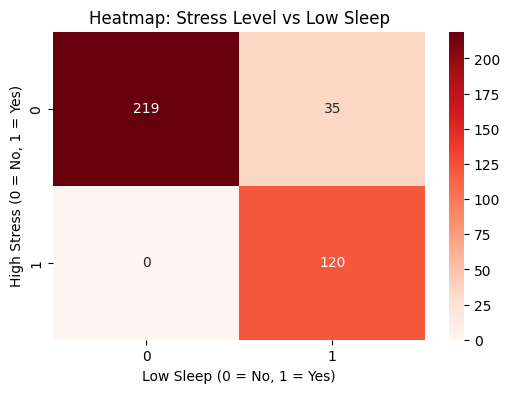

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Reds")
plt.title("Heatmap: Stress Level vs Low Sleep")
plt.xlabel("Low Sleep (0 = No, 1 = Yes)")
plt.ylabel("High Stress (0 = No, 1 = Yes)")
plt.show()